In [88]:
import json
from pathlib import Path

import cv2
import trackpy as tp
import matplotlib.pyplot as plt
import numpy as np
import yaml

CONFIG_PATH = Path('../configs/opencv_tracker_v3.yaml')
config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
input_cfg = config["input"]
base_dir = Path(input_cfg["base_dir"]).resolve()
raw_root = Path(input_cfg.get("raw_root", "/Volumes/Extreme SSD/deep-sea-particles-gm/raw")).resolve()
try:
    relative = base_dir.relative_to(raw_root)
except ValueError:
    relative = Path(base_dir.name)
processed_root = Path(config["output"].get("processed_root", "/Volumes/Extreme SSD/deep-sea-particles-gm/processed")).resolve()
crops_subdir = config["output"].get("crops_subdir", "cropped") or "cropped"
processed_expt_dir = processed_root / relative
crops_dir = processed_expt_dir / crops_subdir
print("crops dir", crops_dir)


crops dir /Volumes/Extreme SSD/deep-sea-particles-gm/processed/plume_particle_2_2024-11-14 17-39-37.245115/cropped


In [90]:
def natural_sort_key(path):
    parts = []
    for token in path.stem.split("_"):
        if token.isdigit():
            parts.append(int(token))
        else:
            parts.append(token.lower())
    return parts

def collect_sequence(folder, extensions=(".png", ".tif", ".bmp")):
    candidates = [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in extensions and not p.name.startswith(".")]
    return sorted(candidates, key=natural_sort_key)


In [91]:
folders = [entry for entry in crops_dir.iterdir() if entry.is_dir()]
if not folders:
    raise RuntimeError("no cropped folders")
sequence = collect_sequence(folders[0])
print("using", folders[0], "with", len(sequence), "frames")

using /Volumes/Extreme SSD/deep-sea-particles-gm/processed/plume_particle_2_2024-11-14 17-39-37.245115/cropped/0_cropped with 268 frames


(np.float64(-0.5), np.float64(799.5), np.float64(799.5), np.float64(-0.5))

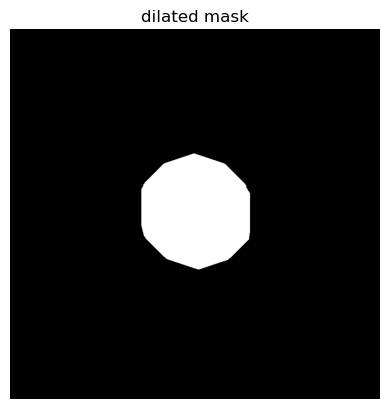

In [93]:
def histogram_stretch(image, lower_pct=0.5, upper_pct=99.5):
    arr = np.asarray(image, dtype=np.float32)
    lo = np.percentile(arr, lower_pct)
    hi = np.percentile(arr, upper_pct)
    if hi <= lo:
        return np.clip(arr, 0, 255).astype(np.uint8)
    stretched = (arr - lo) * (255.0 / (hi - lo))
    return np.clip(stretched, 0, 255).astype(np.uint8)

def build_mask(frame):
    _, mask = cv2.threshold(frame, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    # Keep only the largest contour
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        mask = np.zeros_like(mask)
        cv2.drawContours(mask, [largest_contour], -1, color=255, thickness=cv2.FILLED)
        
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    mask = cv2.dilate(mask, kernel, iterations=20)
    return mask

first = cv2.imread(str(sequence[0]), cv2.IMREAD_GRAYSCALE)
mask = build_mask(first)
plt.imshow(mask, cmap="gray")
plt.title("dilated mask")
plt.axis("off")


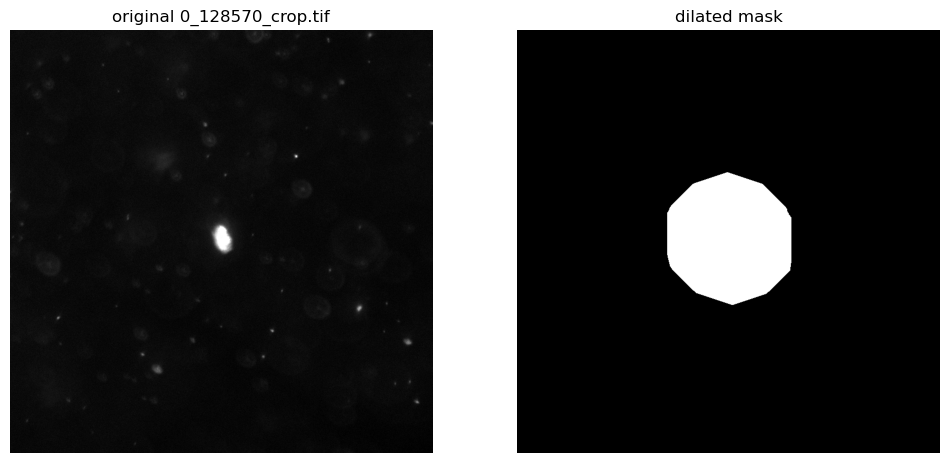

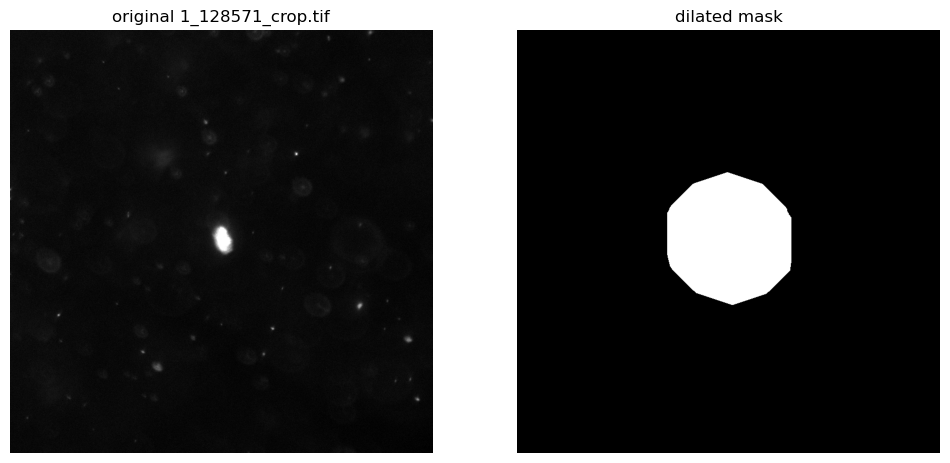

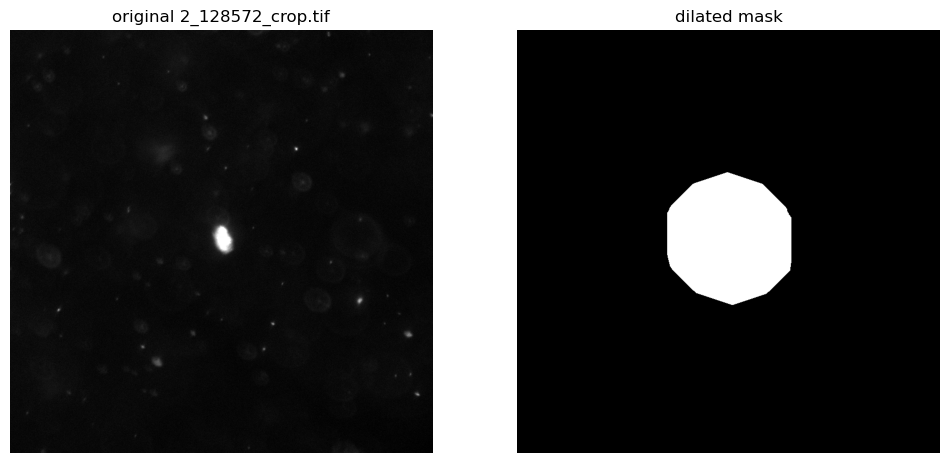

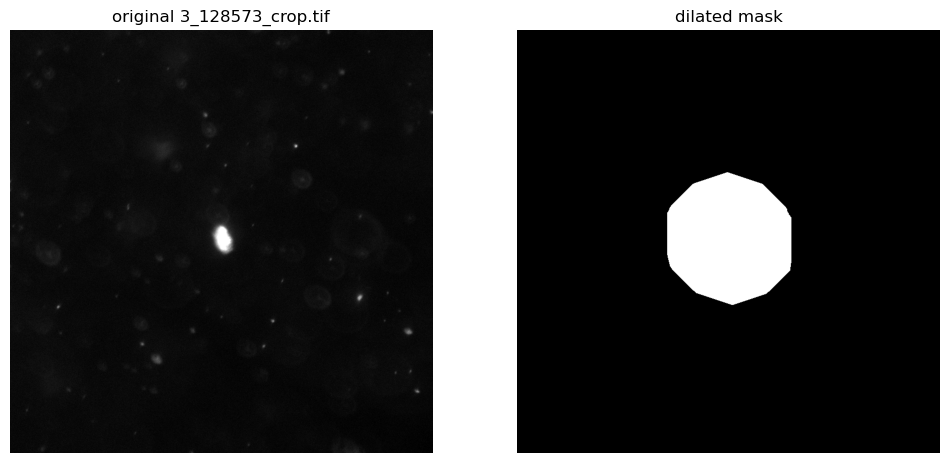

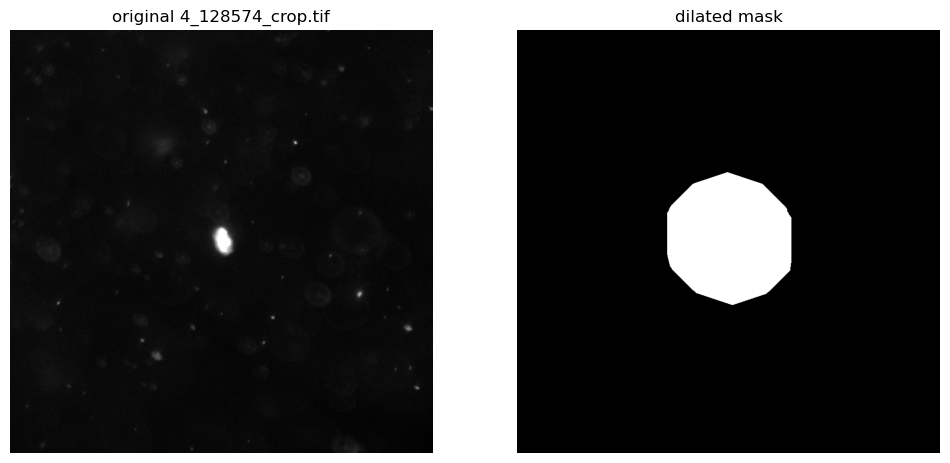

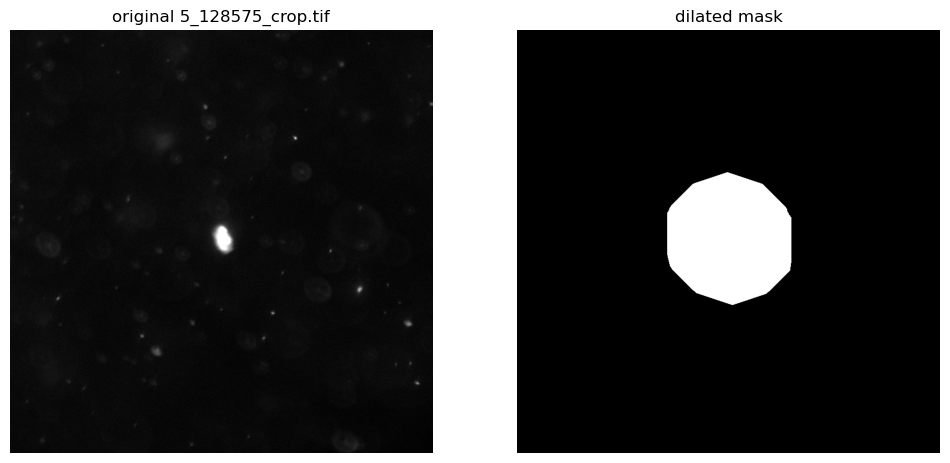

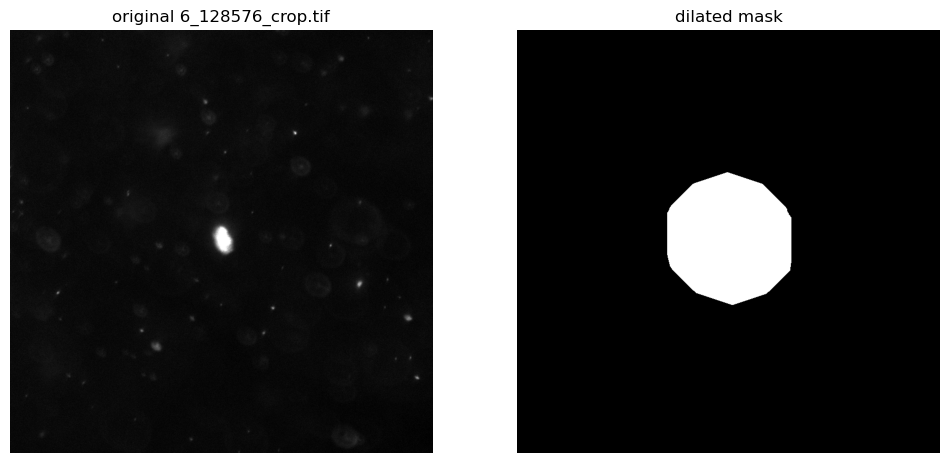

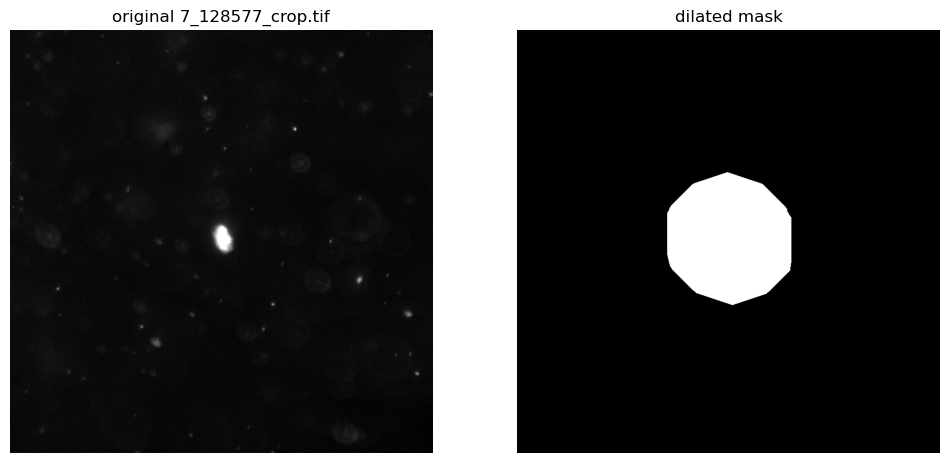

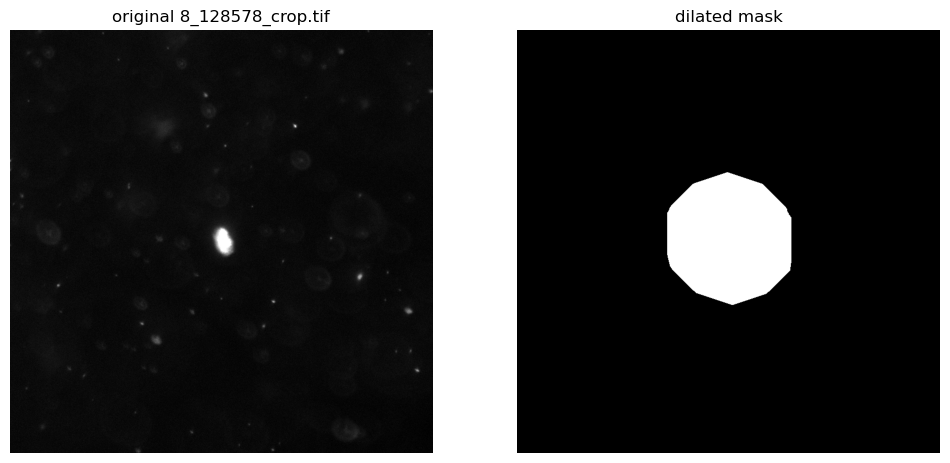

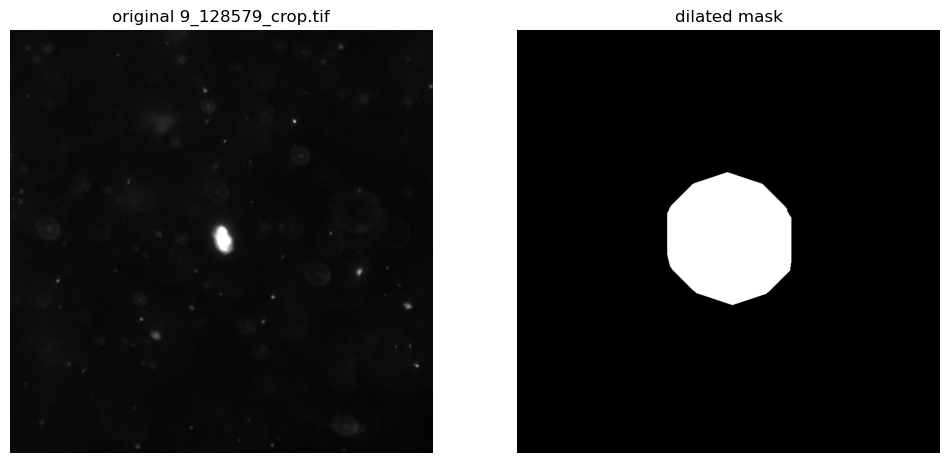

In [94]:
stretched_sequence = []

for image_path in sequence[:10]:
    frame = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    stretched = histogram_stretch(frame, 0.1, 99.9)
    stretched_sequence.append(stretched)
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(stretched, cmap="gray")
    plt.title(f"original {image_path.name}")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("dilated mask")
    plt.axis("off")
    plt.show()

found 36 features in the first frame


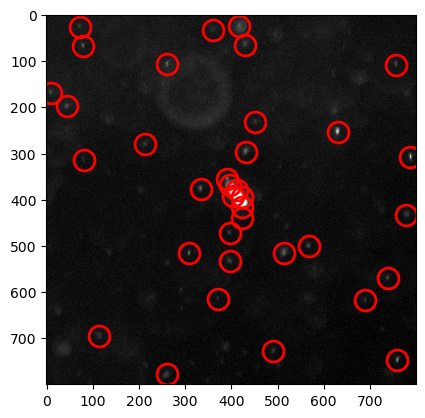

<Axes: >

In [21]:
# Use trackpy to find particles in the first frame
first_frame = cv2.imread(str(sequence[0]), cv2.IMREAD_GRAYSCALE)
first_frame = histogram_stretch(first_frame, 0.1, 99.9)
features = tp.locate(first_frame, 11, minmass=400)
print("found", len(features), "features in the first frame")
features.head()

tp.annotate(features, first_frame)

In [95]:
features = tp.batch(stretched_sequence, 11, minmass=400)
tracks = tp.link(features, 30, memory=3)
tracks_filtered = tp.filter_stubs(tracks, 10)

Frame 9: 34 trajectories present.


In [96]:
tracks_filtered.head()

,y,x,mass,size,ecc,signal,raw_mass,ep,frame,particle
frame,,,,,,,,,,
0,702.999619,769.576323,1449.722294,2.427008,0.228070,71.189256,4364.0,0.156416,0,1
0,700.233121,110.522293,433.205939,2.599363,0.171234,18.763060,2156.0,-0.483287,0,2
0,664.812672,755.584940,600.969767,2.199006,0.118915,36.422410,2257.0,-0.594505,0,4
0,644.648810,281.557900,1019.827484,3.201055,0.126892,23.729752,5775.0,0.084739,0,5
0,617.256222,478.703620,975.679108,2.097591,0.040593,56.841034,3117.0,0.619594,0,6


In [97]:
def filter_tracks_by_mask(tracks, mask, ycol='y', xcol='x', particle_col='particle',
                          drop_entire_track=True):
    h, w = mask.shape

    yy = np.rint(tracks[ycol].to_numpy()).astype(int)
    xx = np.rint(tracks[xcol].to_numpy()).astype(int)

    yy = np.clip(yy, 0, h - 1)
    xx = np.clip(xx, 0, w - 1)

    inside = mask[yy, xx].astype(bool)

    out = tracks.copy()
    out['inside_mask'] = inside

    if drop_entire_track:
        bad_particles = out.groupby(particle_col)['inside_mask'].any()
        bad_particles = bad_particles[bad_particles].index
        out = out.loc[~out[particle_col].isin(bad_particles)].copy()
    else:
        out = out.loc[~out['inside_mask']].copy()

    return out.drop(columns='inside_mask')

In [98]:
tracks_filtered = filter_tracks_by_mask(tracks_filtered, mask, drop_entire_track=True)

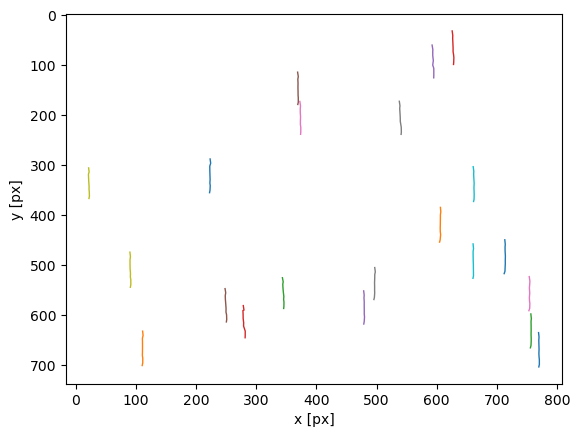

<Axes: xlabel='x [px]', ylabel='y [px]'>

In [99]:
plt.figure()
tp.plot_traj(tracks_filtered)

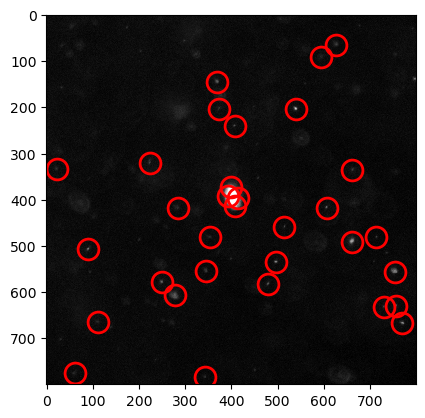

<Axes: >

In [100]:
tp.annotate(features.loc[features['frame']==5], stretched_sequence[5])

In [101]:
import numpy as np
import pandas as pd

def compute_particle_velocities(tracks):
    """
    Compute one mean velocity vector per particle from start/end positions,
    using elapsed frame intervals: (end_frame - start_frame).

    Parameters
    ----------
    tracks : pandas.DataFrame
        Must contain columns: particle, frame, x, y

    Returns
    -------
    particle_vel : pandas.DataFrame
        One row per particle with vx, vy, speed, and track summary info.
    """
    tracks = tracks.reset_index(drop=True).copy()

    rows = []

    for pid, grp in tracks.groupby('particle'):
        grp = grp.sort_values('frame')

        start = grp.iloc[0]
        end = grp.iloc[-1]

        start_frame = int(start['frame'])
        end_frame = int(end['frame'])
        n_steps = end_frame - start_frame

        # skip degenerate tracks
        if n_steps <= 0:
            continue

        dx = end['x'] - start['x']
        dy = end['y'] - start['y']

        vx = dx / n_steps
        vy = dy / n_steps

        rows.append({
            'particle': pid,
            'start_frame': start_frame,
            'end_frame': end_frame,
            'n_steps': n_steps,
            'x_start': start['x'],
            'y_start': start['y'],
            'x_end': end['x'],
            'y_end': end['y'],
            'dx': dx,
            'dy': dy,
            'vx': vx,
            'vy': vy,
            'speed': np.sqrt(vx**2 + vy**2),
        })

    return pd.DataFrame(rows)


def summarize_particle_velocities(particle_vel):
    """
    Average particle velocities across particles and return mean/std.
    """
    return {
        'n_particles': len(particle_vel),
        'mean_vx': particle_vel['vx'].mean(),
        'std_vx': particle_vel['vx'].std(ddof=1),
        'mean_vy': particle_vel['vy'].mean(),
        'std_vy': particle_vel['vy'].std(ddof=1),
        'mean_speed': particle_vel['speed'].mean(),
        'std_speed': particle_vel['speed'].std(ddof=1),
    }

In [102]:
particle_vel = compute_particle_velocities(tracks_filtered)
summary = summarize_particle_velocities(particle_vel)

In [103]:
summary

{'n_particles': 21,
 'mean_vx': np.float64(-0.06644238736077902),
 'std_vx': np.float64(0.16203284330855272),
 'mean_vy': np.float64(-7.396088254913642),
 'std_vy': np.float64(0.2767532513535589),
 'mean_speed': np.float64(7.398109032713866),
 'std_speed': np.float64(0.27584733114890114)}

In [ ]:
# Convert the velocity to physical units

mean_speed_pixels_per_frame = summary['mean_speed']
std_speed_pixels_per_frame = summary['std_speed']

frame_rate_fps = 16.7  # frames per second
pixel_size_um = 1.36  # microns per pixel

mean_speed_um_per_s = mean_speed_pixels_per_frame * frame_rate_fps * pixel_size_um
std_speed_um_per_s = std_speed_pixels_per_frame * frame_rate_fps * pixel_size_um

print(f"mean speed: {mean_speed_um_per_s:.2f} um/s")
print(f"std speed: {std_speed_um_per_s:.2f} um/s")

mean speed: 90.84 um/s
std speed: 3.39 um/s
